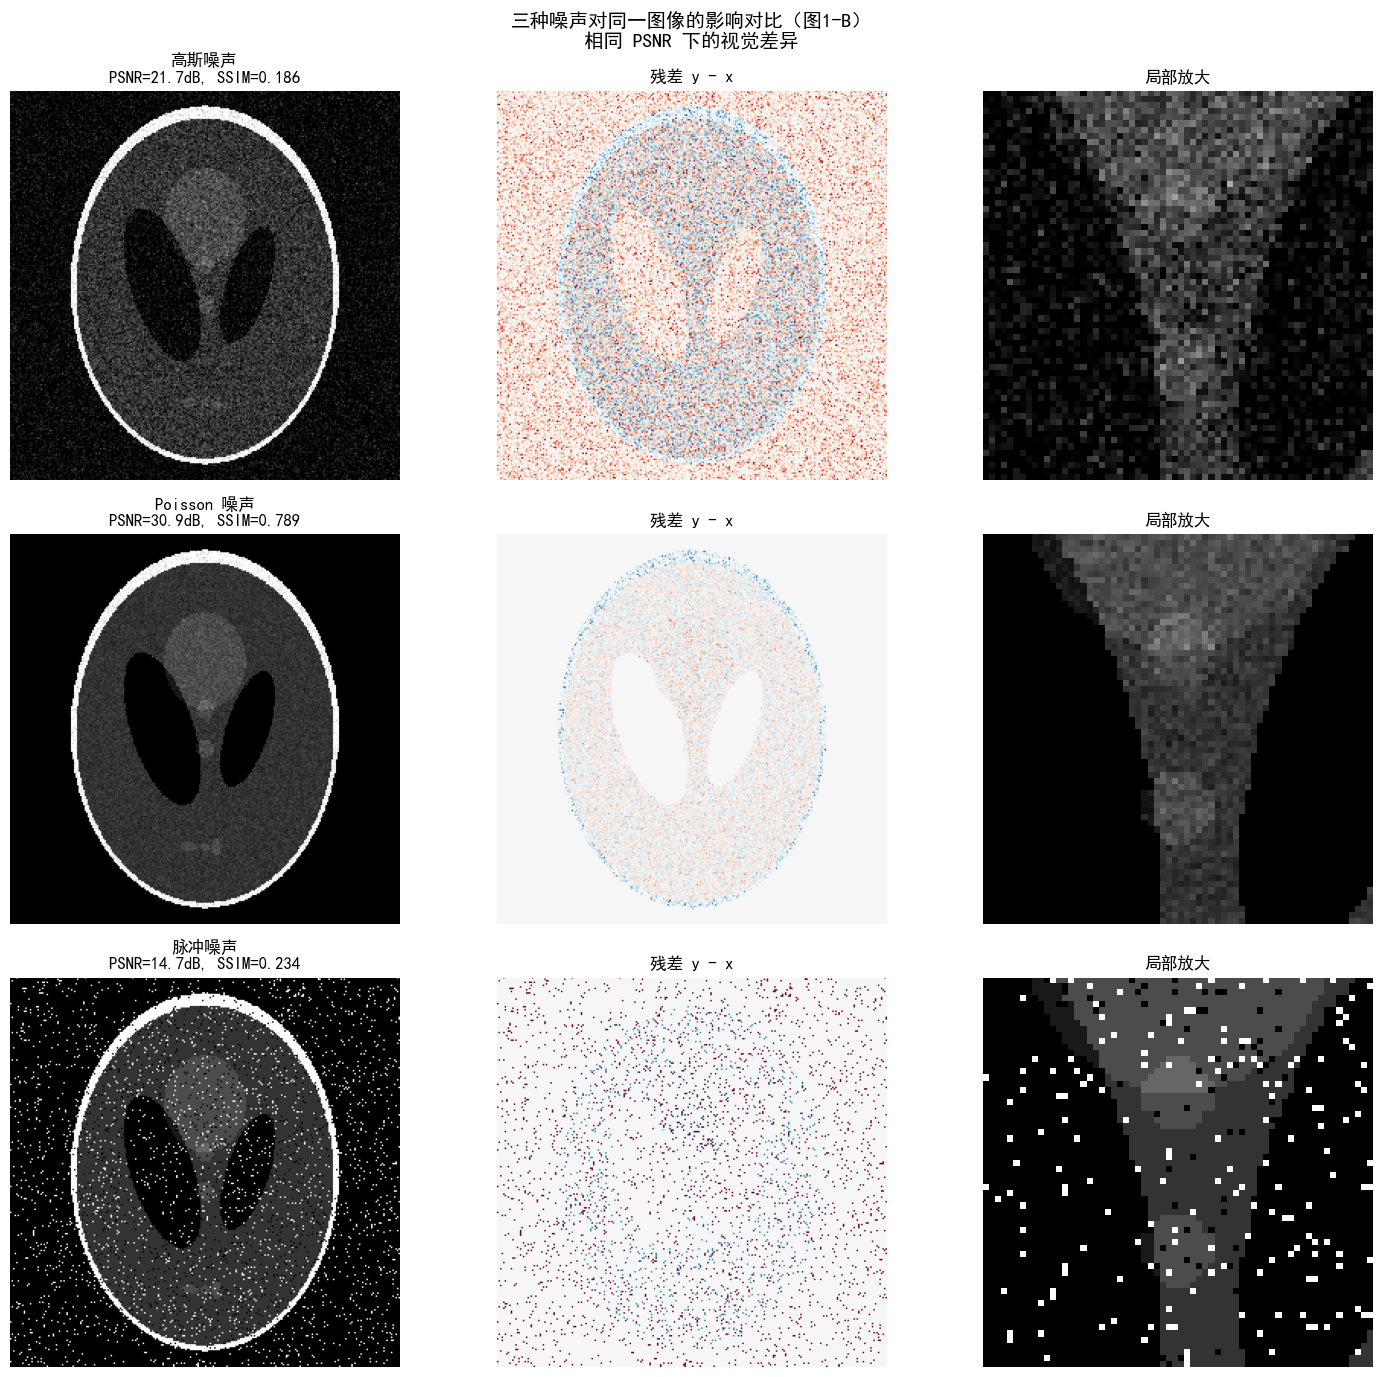


=== 数据项匹配的重要性 ===
脉冲噪声 + L2去噪(均值滤波): PSNR = 20.6dB
脉冲噪声 + L1去噪(中值滤波): PSNR = 27.6dB
→ L1 数据项（中值滤波）更适合脉冲噪声，这就是'数据项由噪声机制决定'的实践含义


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib as mpl

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 加载图像 ----
n = 256
x = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=False)
x = x / x.max()

# ---- 2. 添加三种噪声（调节到 PSNR ≈ 20dB）----
# 高斯噪声
sigma_g = 0.10
y_gauss = x + sigma_g * np.random.randn(n, n)
y_gauss = np.clip(y_gauss, 0, 1)

# Poisson 噪声
gain = 0.008
y_poisson = np.random.poisson(np.maximum(x / gain, 0)).astype(np.float64) * gain
y_poisson = np.clip(y_poisson, 0, 1)

# 脉冲噪声
y_sp = random_noise(x, mode='s&p', amount=0.08)

# ---- 3. 计算度量 ----
psnr_g = peak_signal_noise_ratio(x, y_gauss)
psnr_p = peak_signal_noise_ratio(x, y_poisson)
psnr_s = peak_signal_noise_ratio(x, y_sp)
ssim_g = structural_similarity(x, y_gauss, data_range=1.0)
ssim_p = structural_similarity(x, y_poisson, data_range=1.0)
ssim_s = structural_similarity(x, y_sp, data_range=1.0)

# ---- 4. 验证"错误数据项"的后果 ----
# 用 L2 去噪处理脉冲噪声（不匹配的数据项）
x_l2_denoise = y_sp.copy()  # 简单均值滤波
from scipy.ndimage import uniform_filter
x_l2_denoise = uniform_filter(y_sp, size=3)

# 用中值滤波处理脉冲噪声（匹配的数据项）
from scipy.ndimage import median_filter
x_median = median_filter(y_sp, size=3)

psnr_l2 = peak_signal_noise_ratio(x, x_l2_denoise)
psnr_median = peak_signal_noise_ratio(x, x_median)

# ---- 5. 可视化 ----
fig, axes = plt.subplots(3, 3, figsize=(15, 14))

imgs = [y_gauss, y_poisson, y_sp]
names = ['高斯噪声', 'Poisson 噪声', '脉冲噪声']
psnrs = [psnr_g, psnr_p, psnr_s]
ssims = [ssim_g, ssim_p, ssim_s]

for i, (img, name) in enumerate(zip(imgs, names)):
    # 含噪图像
    axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f'{name}\nPSNR={psnrs[i]:.1f}dB, SSIM={ssims[i]:.3f}')
    axes[i, 0].axis('off')

    # 噪声残差
    residual = img - x
    vmax = 0.3
    axes[i, 1].imshow(residual, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i, 1].set_title(f'残差 y - x')
    axes[i, 1].axis('off')

    # 局部放大（中心区域）
    cx, cy = n // 2, n // 2
    r = 32
    crop = img[cx - r:cx + r, cy - r:cy + r]
    axes[i, 2].imshow(crop, cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title('局部放大')
    axes[i, 2].axis('off')

plt.suptitle('三种噪声对同一图像的影响对比（图1-B）\n相同 PSNR 下的视觉差异', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_9_三种噪声对比_图1B.png', dpi=150, bbox_inches='tight')
plt.show()

# 数据项匹配 vs 不匹配
print(f"\n=== 数据项匹配的重要性 ===")
print(f"脉冲噪声 + L2去噪(均值滤波): PSNR = {psnr_l2:.1f}dB")
print(f"脉冲噪声 + L1去噪(中值滤波): PSNR = {psnr_median:.1f}dB")
print("→ L1 数据项（中值滤波）更适合脉冲噪声，这就是'数据项由噪声机制决定'的实践含义")